In [1]:
import numpy as np
import dpluspy
import pickle 
import matplotlib.pyplot as plt 
import matplotlib 
import scipy
import demes 
import demesdraw
from matplotlib.transforms import ScaledTranslation

In [2]:
matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = "Computer Modern"
matplotlib.rcParams["savefig.bbox"] = "tight"
matplotlib.rcParams["axes.linewidth"] = 0.5
matplotlib.rcParams["font.size"] = 9
matplotlib.rcParams['xtick.labelsize'] = 9
matplotlib.rcParams['ytick.labelsize'] = 9
lw = 1

In [8]:
# file names

bherer_data_file = "../data/statistics/main/stats_Bherer_weighted.pkl"
zhou_data_file = "../data/statistics/main/stats_ZhouJHS_weighted.pkl"

_model_cache = {}

In [72]:
def load_pkl(fname):
    with open(fname, "rb") as fin: 
        ret = pickle.load(fin)
    return ret


lw = 1.1


def plot_stats_on_axs(
    stats, 
    axs, 
    mapping, 
    colors, 
    linestyle, 
    kwargs={},
    labels=None, 
    fill=True,
    ylabel="$D^+$",
    plot_sqrhet=False
):
    """
    mapping looks like {(0, 0): 0}

    :param plot_sqrhet: If True, plot H^2.
    """

    shape = axs.shape
    axs = axs.flatten()
    ax_tracker = np.zeros(len(axs), np.int64)
    means = np.array(stats["means"])[:-1]
    if plot_sqrhet:
        hets = np.array(stats["means"])[-1] 
    if fill:
        varcovs = np.array(stats["varcovs"])[:-1]
    bins = stats["bins"]
    xx = (bins[1:] + bins[:-1]) / 2
    pop_ids = stats["pop_ids"]
    statistics = dpluspy.utils._DP_names(list(range(len(pop_ids))))
    for (idx0, idx1), ax_idx in mapping.items():
        ax = axs[ax_idx]
        if labels is not None:
            if idx0 == idx1:
                label = labels[idx0]
            else:
                label = f"{labels[idx0]},{labels[idx1]}"
        else:
            label = None
        identifier = f"D+_{idx0}_{idx1}"
        idx = statistics.index(identifier)
        yy = means[:, idx]
        # pick the color based on how many curves have been plotted so far
        color = colors[ax_tracker[ax_idx]]
        if fill:
            err = varcovs[:, idx, idx] ** 0.5 * 1.96
            ax.fill_between(xx, yy - err, yy + err, alpha=0.3, color=color,
                            edgecolor="none")
        if linestyle is not None:
            ax.plot(xx, yy, linestyle, color=color, label=label, lw=lw, **kwargs)

        if plot_sqrhet:
            H2 = hets[idx] ** 2
            ax.scatter([0.03], [H2], marker="x", color=color)

        ax_tracker[ax_idx] += 1
    for ax in axs: 
        ax.set_xscale("log")
        ax.legend(framealpha=0, fontsize="x-small")
    # label axes of subplots at the left and bottom edges
    for ax in axs[-shape[1]:]:
        ax.set_xlabel("$r$")
    for ii in range(len(axs)):
        if ii % shape[1] == 0:
            axs[ii].set_ylabel(ylabel)
    return


def compute_residuals(data, model):
    varcovs = data["varcovs"]
    stds = [v[np.diag_indices(len(varcovs[0]))] ** 0.5 for v in varcovs]
    residuals = np.array(model) - np.array(data["means"])
    scaled_residuals = residuals / stds
    return scaled_residuals

mapping = {
    # one-pop
    (0, 0): 0, # Altai
    (1, 1): 1, # Vindija
    (2, 2): 2, # Chagyrskaya
    (3, 3): 3, # Denisova
    (4, 4): 4, # Stuttgart
    (5, 5): 5, # Loschbour
    (6, 6): 6, # Ust"Ishim
    (7, 7): 7, # Yoruba1
    
    # neanderthal-neanderthal
    (0, 1): 8,
    (0, 2): 9,
    (1, 2): 10,

    # neanderthal-denisovan
    (1, 3): 11,
    (0, 3): 12,
    (2, 3): 13,

    # neanderthal-human
    (0, 4): 14,
    (0, 6): 15,
    (0, 7): 16,
    (0, 5): 17,
    (1, 4): 18,
    (1, 6): 19,
    (1, 7): 20,
    (1, 5): 21,
    (2, 4): 22,
    (2, 6): 23,
    (2, 7): 24,
    (2, 5): 25,
    
    # denisovan-human
    (3, 4): 26,
    (3, 6): 27,
    (3, 7): 28,
    (3, 5): 29,

    # human-human
    (4, 6): 30,
    (4, 5): 31,
    (4, 7): 32,
    (5, 7): 33,
    (6, 7): 34,
    (5, 6): 34,
}

mapping_hn = {
    # one-pop
    (0, 0): 0, # Altai
    (1, 1): 1, # Vindija
    (2, 2): 2, # Chagyrskaya
    (3, 3): 3, # Denisova
    (4, 4): 4, # Loschbour
    (5, 5): 5, # Yoruba1
    
    # neanderthal-neanderthal
    (0, 1): 6,
    (0, 2): 7,
    (1, 2): 8,

    # neanderthal-denisovan
    (1, 3): 9,
    (0, 3): 10,
    (2, 3): 11,

    # neanderthal-human
    (0, 4): 12,
    (0, 5): 13,
    (1, 4): 14,
    (1, 5): 15,
    (2, 4): 16,
    (2, 5): 17,
    
    # denisovan-human
    (3, 4): 18,
    (3, 5): 19,

    # human-human
    (4, 5): 19,
}

mapping_sd = {
    # one-pop
    (0, 0): 0, # Altai
    (1, 1): 1, # Vindija
    (2, 2): 2, # Chagyrskaya
    (3, 3): 3, # Denisova
    (4, 4): 4, # Yoruba1
    
    # neanderthal-neanderthal
    (0, 1): 5,
    (0, 2): 6,
    (1, 2): 7,

    # neanderthal-denisovan
    (1, 3): 8,
    (0, 3): 9,
    (2, 3): 10,

    # neanderthal-human
    (0, 4): 11,
    (1, 4): 12,
    (2, 4): 13,
    
    # denisovan-human
    (3, 4): 14
}

mapping_mh = {
    # one-pop
    (0, 0): 0, # Vindija
    (1, 1): 1, # Stuttgart
    (2, 2): 2, # Loschbour
    (3, 3): 3, # Ust'Ishim
    (4, 4): 4, # Yoruba1

    # neanderthal-human
    (0, 1): 5,
    (0, 2): 6,
    (0, 3): 7,
    (0, 4): 8,

    # human-human
    (1, 2): 9,
    (1, 3): 10,
    (1, 4): 11,
    (2, 3): 12,
    (2, 4): 13,
    (3, 4): 14,
}


/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


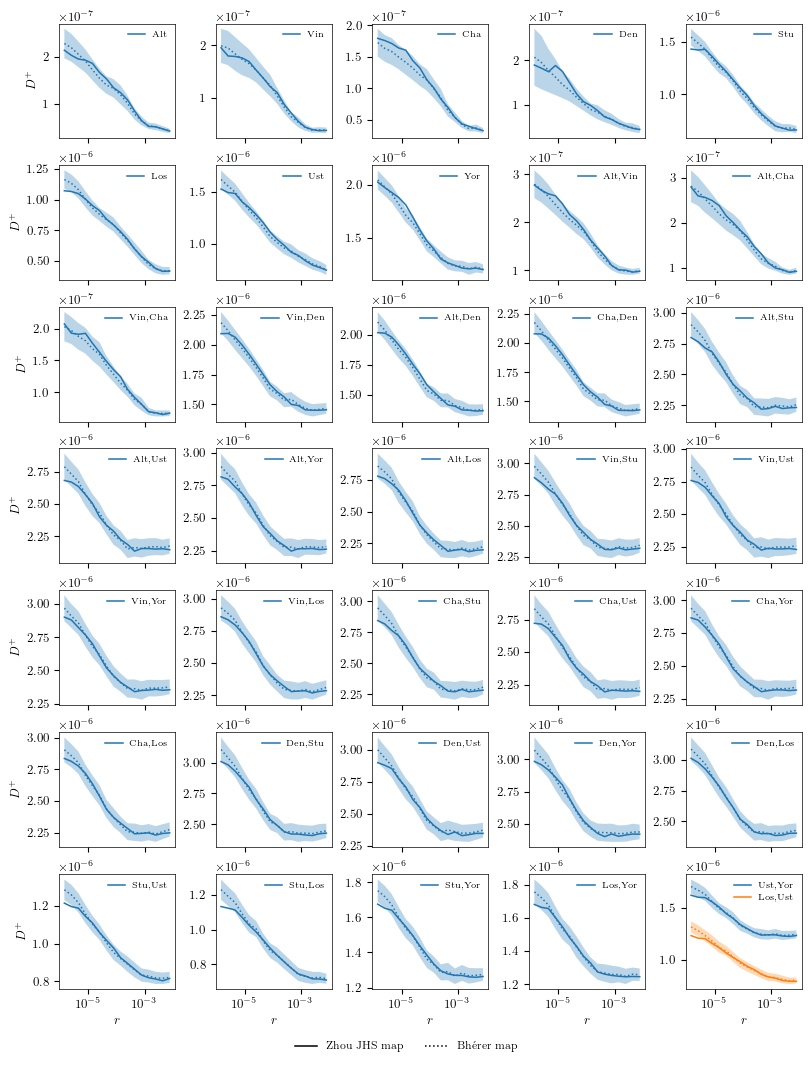

In [73]:
def plot_recombination_map_comp2(axs):
    bherer = load_pkl(bherer_data_file)
    zhou = load_pkl(zhou_data_file)
    labels = [x[:3] for x in bherer["pop_ids"]]
    # labels = [str(x) for x in list(range(10))]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(bherer, axs, mapping, colors, ":", 
        labels=None, fill=True)
    plot_stats_on_axs(zhou, axs, mapping, colors, "-", 
        labels=labels, fill=False)
    return

fig, axs = plt.subplots(7, 5, figsize=(8, 10.25), layout="constrained", sharex=1)
plot_recombination_map_comp2(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Zhou JHS map"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Bhérer map", 
                            linestyle=":")
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.03))
plt.savefig("figures/figS1.pdf")

/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


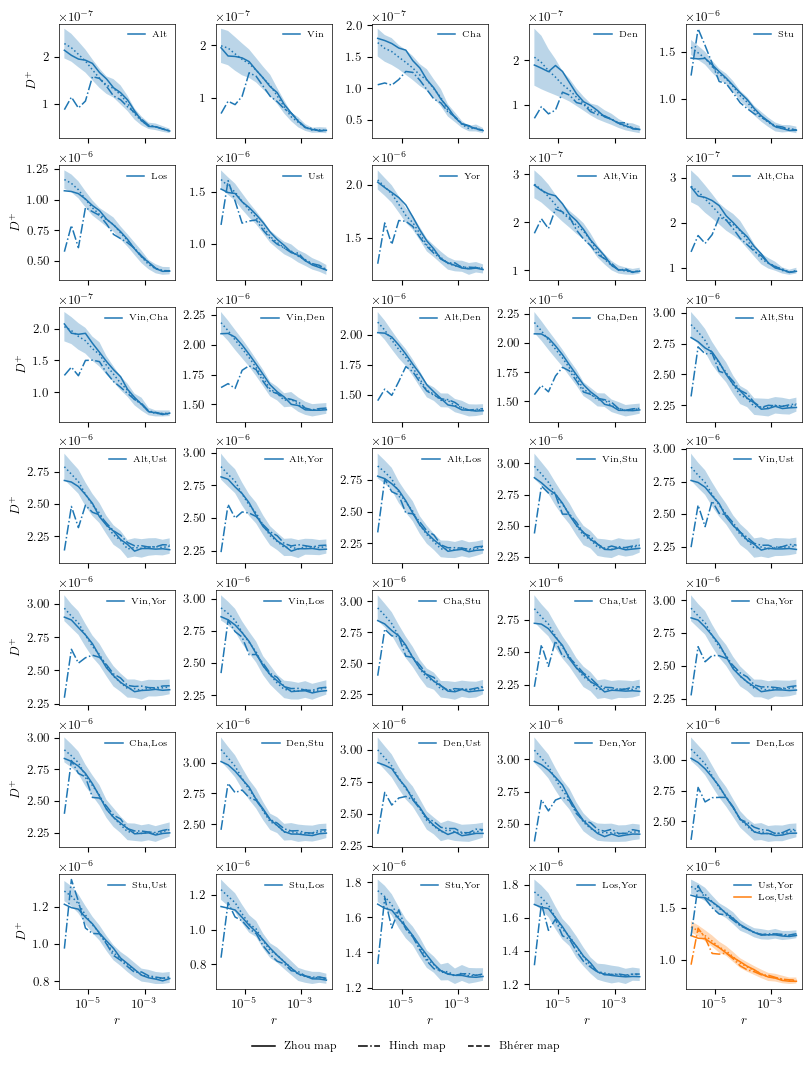

In [74]:
def plot_recombination_map_comp3(axs):
    bherer = load_pkl(bherer_data_file)
    zhou = load_pkl(zhou_data_file)
    hinch = load_pkl(
        "../analyses/recombination_maps/results/stats/stats_Hinch.pkl")
    labels = [x[:3] for x in bherer["pop_ids"]]
    # labels = [str(x) for x in list(range(10))]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(bherer, axs, mapping, colors, ":",
        labels=None, fill=True)
    plot_stats_on_axs(zhou, axs, mapping, colors, "-", labels=labels, 
        fill=False)
    plot_stats_on_axs(hinch, axs, mapping, colors, "-.", 
        labels=None, fill=False)
    return

fig, axs = plt.subplots(
    7, 5, figsize=(8, 10.25), layout="constrained", sharex=1)
plot_recombination_map_comp3(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Zhou map", 
                            linestyle="-"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Hinch map", 
                            linestyle="-."),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Bhérer map", 
                            linestyle="--"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4,
           bbox_to_anchor=(0.5, -0.03))

/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


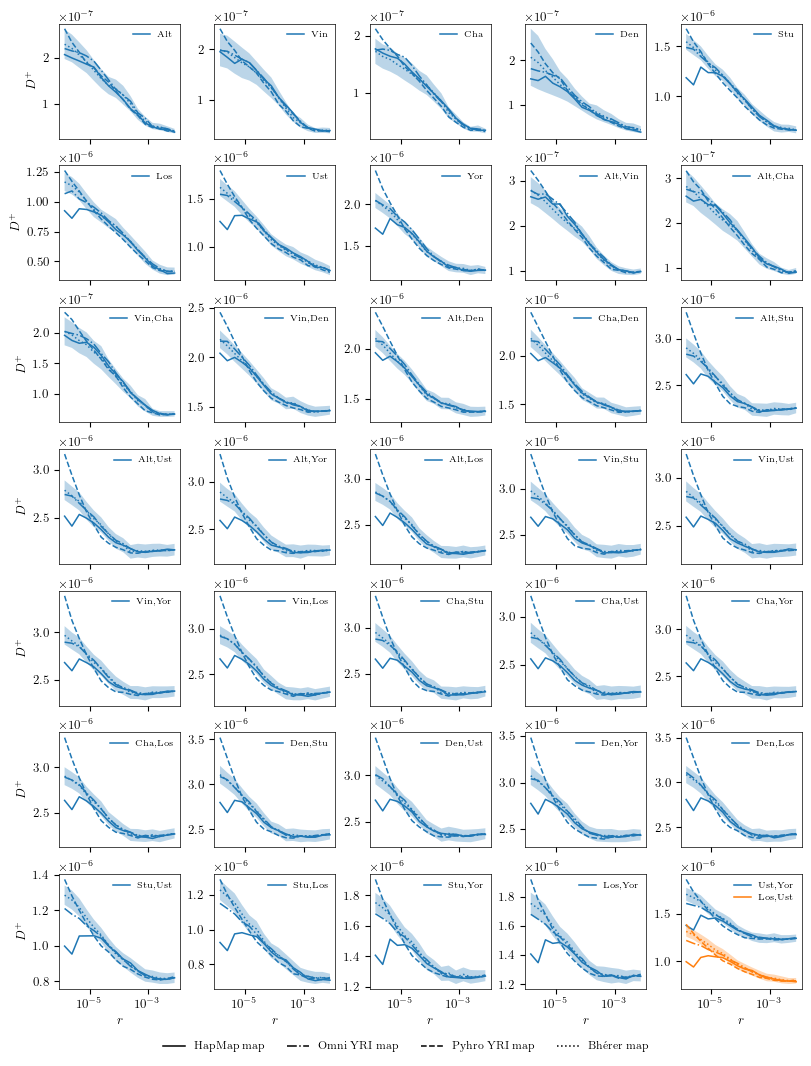

In [75]:
def plot_recombination_map_comp4(axs):
    bherer = load_pkl(bherer_data_file)
    hapmap = load_pkl("../analyses/recombination_maps/results/stats/stats_hapmap.pkl")
    omniYRI = load_pkl("../analyses/recombination_maps/results/stats/stats_omniYRI.pkl")
    pyrhoYRI = load_pkl("../analyses/recombination_maps/results/stats/stats_pyrhoYRI.pkl")
    labels = [x[:3] for x in bherer["pop_ids"]]
    # labels = [str(x) for x in list(range(10))]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(bherer, axs, mapping, colors, ":",
        labels=None, fill=True)
    plot_stats_on_axs(hapmap, axs, mapping, colors, "-", labels=labels, 
        fill=False)
    plot_stats_on_axs(omniYRI, axs, mapping, colors, "-.", 
        labels=None, fill=False)
    plot_stats_on_axs(pyrhoYRI, axs, mapping, colors, "--", 
        labels=None, fill=False)
    return

fig, axs = plt.subplots(7, 5, figsize=(8, 10.25), layout="constrained", sharex=1)
plot_recombination_map_comp4(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="HapMap map", 
                            linestyle="-"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Omni YRI map", 
                            linestyle="-."),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Pyhro YRI map", 
                            linestyle="--"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Bhérer map", 
                            linestyle=":"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4,
           bbox_to_anchor=(0.5, -0.03))
plt.savefig("figures/figS2.pdf")

/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


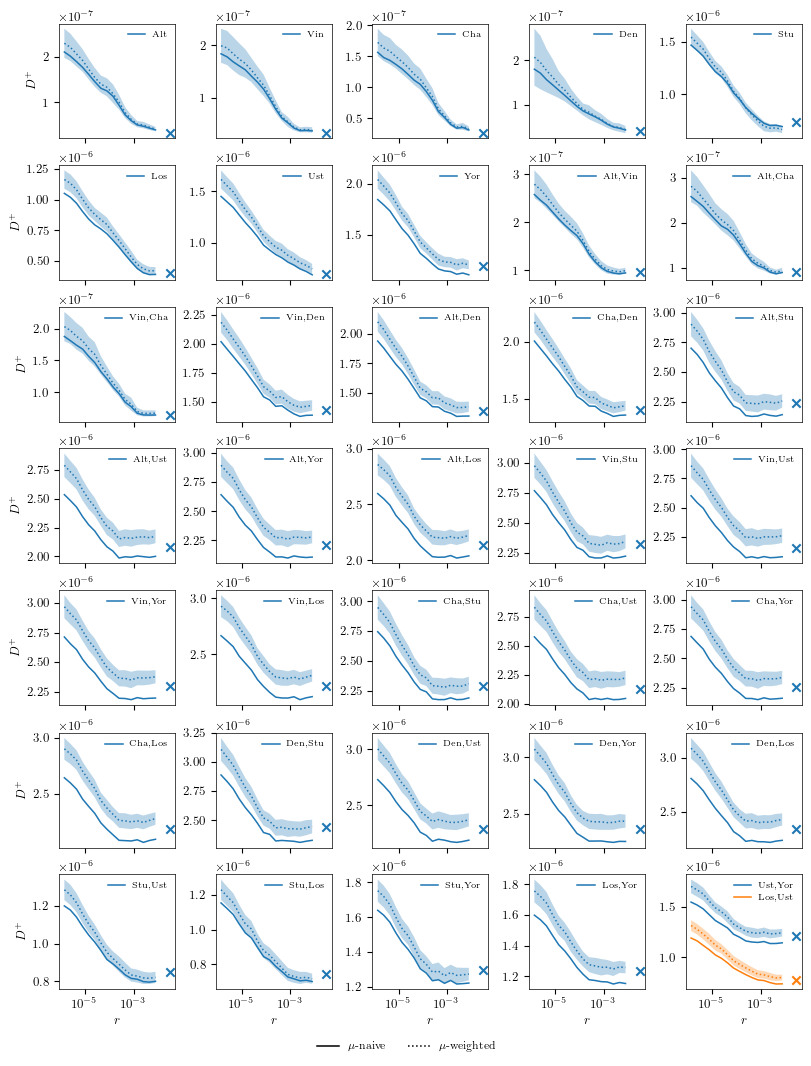

In [76]:
def plot_weighted_and_naive(axs):
    weighted = load_pkl("../data/statistics/main/stats_Bherer_weighted.pkl")
    naive = load_pkl("../data/statistics/main/stats_Bherer_naive.pkl")
    labels = [x[:3] for x in weighted["pop_ids"]]
    # labels = [str(x) for x in list(range(10))]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(weighted, axs, mapping, colors, ":", 
        labels=None, fill=True, plot_sqrhet=True)
    plot_stats_on_axs(naive, axs, mapping, colors, "-", 
        labels=labels, fill=False)
    return

fig, axs = plt.subplots(7, 5, figsize=(8, 10.25), layout="constrained", sharex=1)
plot_weighted_and_naive(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label=r"$\mu$-naive"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", linestyle=":", 
                            label=r"$\mu$-weighted")
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.03))
plt.savefig("figures/figS3.pdf")

/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


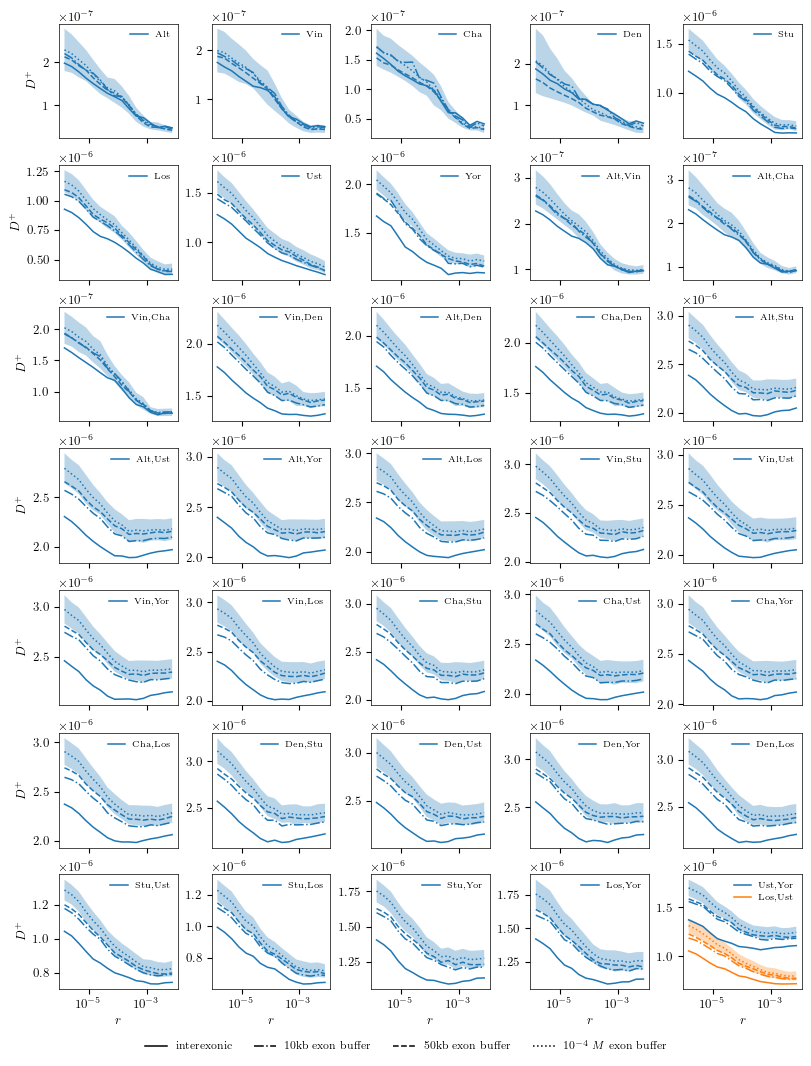

In [77]:
def plot_exon_masking_comp(axs):
    data0 = load_pkl("../analyses/exon_buffers/results/stats/stats_intergenic.pkl")
    data1 = load_pkl("../analyses/exon_buffers/results/stats/stats_10kb_exon_buffer.pkl")
    data2 = load_pkl("../analyses/exon_buffers/results/stats/stats_50kb_exon_buffer.pkl")
    data3 = load_pkl("../analyses/exon_buffers/results/stats/stats_1e-4M_exon_buffer.pkl")

    labels = [x[:3] for x in data0["pop_ids"]]
    # labels = [str(x) for x in list(range(10))]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(data3, axs, mapping, colors, ":",  labels=None, fill=True)
    plot_stats_on_axs(data0, axs, mapping, colors, "-", labels=labels, fill=False)
    plot_stats_on_axs(data1, axs, mapping, colors, "-.", labels=None, fill=False)
    plot_stats_on_axs(data2, axs, mapping, colors, "--", labels=None, fill=False)
    return

fig, axs = plt.subplots(7, 5, figsize=(8, 10.25), layout="constrained", sharex=1)
plot_exon_masking_comp(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="interexonic"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", linestyle="-.", 
                            label="$10$kb exon buffer"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", linestyle="--", 
                            label="$50$kb exon buffer"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", linestyle=":", 
                            label="$10^{-4}$ $M$ exon buffer"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4,
           bbox_to_anchor=(0.5, -0.03))
plt.savefig("figures/figS4.pdf")

/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


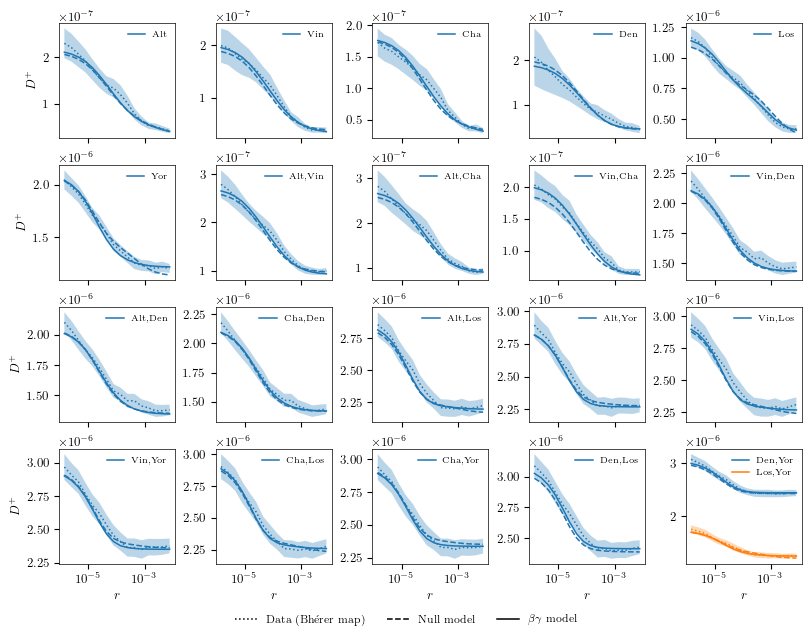

In [85]:
def __plot_hn_model_residuals(axs):
    graph0 = "../models/human_neanderthal/main/fitted_models/null_Bherer_fit_10.yaml"
    graph1 = "../models/human_neanderthal/main/fitted_models/pulses_Bherer_fit_4.yaml"
    bherer = dpluspy.inference.load_stats(
        "../data/statistics/main/stats_Bherer_weighted.pkl", 
        graph=graph0, return_dict=True)
    model0 = dpluspy.inference.compute_bin_stats(
        graph0, sampled_demes=bherer["pop_ids"], bins=bherer["bins"], u=1.3e-8)
    residuals0 = compute_residuals(bherer, model0)
    plot_me0 = {
        "means": residuals0, "bins": bherer["bins"], "pop_ids": bherer["pop_ids"]}
    model1 = dpluspy.inference.compute_bin_stats(
        graph1, sampled_demes=bherer["pop_ids"], bins=bherer["bins"], u=1.3e-8)
    residuals1 = compute_residuals(bherer, model1)
    plot_me1 = {
        "means": residuals1, "bins": bherer["bins"], "pop_ids": bherer["pop_ids"]}
    
    labels = [x[:3] for x in bherer["pop_ids"]]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(plot_me0, axs, mapping_hn, colors, "--", labels=None, 
                      fill=False)
    plot_stats_on_axs(plot_me1, axs, mapping_hn, colors, "-", labels=labels, 
                      fill=False, ylabel="residual")
    return


def plot_hn_model_fits(axs):
    graph0 = "../models/human_neanderthal/main/fitted_models/null_Bherer_fit_10.yaml"
    graph1 = "../models/human_neanderthal/main/fitted_models/pulses_Bherer_fit_4.yaml"
    data = dpluspy.inference.load_stats(
        "../data/statistics/main/stats_Bherer_weighted.pkl", 
        graph=graph0, return_dict=True)
    
    if graph0 in _model_cache:
        _model0 = _model_cache[graph0]
    else:
        _model0 = dpluspy.inference.compute_bin_stats(
            graph0, sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
        _model_cache[graph0] = _model0
    model0 = {
        "means": _model0, "bins": data["bins"], "pop_ids": data["pop_ids"]}
    
    if graph1 in _model_cache:
        _model1 = _model_cache[graph1]
    else:
        _model1 = dpluspy.inference.compute_bin_stats(
            graph1, sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
        _model_cache[graph1] = _model1
    model1 = {
        "means": _model1, "bins": data["bins"], "pop_ids": data["pop_ids"]}
    
    labels = [x[:3] for x in data["pop_ids"]]
    colors = ["tab:blue", "tab:orange"]
    plot_stats_on_axs(data, axs, mapping_hn, colors, ":", labels=None, 
                      fill=True)
    plot_stats_on_axs(model0, axs, mapping_hn, colors, "--", labels=None, 
                      fill=False)
    plot_stats_on_axs(model1, axs, mapping_hn, colors, "-", labels=labels, 
                      fill=False)
    return



fig, axs = plt.subplots(4, 5, figsize=(8, 6), layout="constrained", 
                        sharex=1)
plot_hn_model_fits(axs)
labels = [
    matplotlib.lines.Line2D([], [], color="black", label="Data (Bhérer map)", lw=lw,
                            linestyle=":"),
    matplotlib.lines.Line2D([], [], color="black", label="Null model", lw=lw,
                            linestyle="--"),
    matplotlib.lines.Line2D([], [], color="black", label=r"$\beta \gamma$ model",
                            linestyle="-", lw=lw)
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/figS5.pdf")


/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


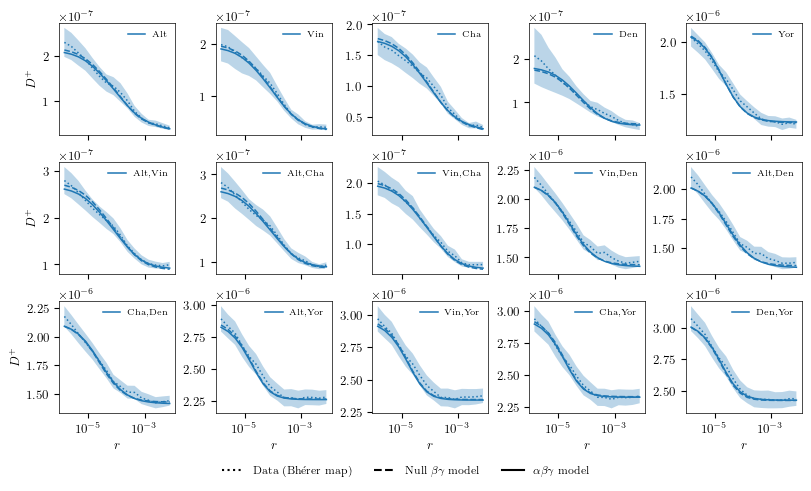

In [ ]:
def __plot_superarchaic_residuals(axs):
    graph0 = "../models/ghost_introgression/main/fitted_models/null_Bherer_fit_16.yaml"
    graph1 = "../models/ghost_introgression/main/fitted_models/fixed_2Ma_Bherer_fit_2.yaml"
    bherer = dpluspy.inference.load_stats(
        "../data/statistics/main/stats_Bherer_weighted.pkl", 
        graph=graph0, return_dict=True)
    model0 = dpluspy.inference.compute_bin_stats(
        graph0, sampled_demes=bherer["pop_ids"], bins=bherer["bins"], u=1.3e-8)
    residuals0 = compute_residuals(bherer, model0)
    plot_me0 = {
        "means": residuals0, "bins": bherer["bins"], "pop_ids": bherer["pop_ids"]}
    model1 = dpluspy.inference.compute_bin_stats(
        graph1, sampled_demes=bherer["pop_ids"], bins=bherer["bins"], u=1.3e-8)
    residuals1 = compute_residuals(bherer, model1)
    plot_me1 = {
        "means": residuals1, "bins": bherer["bins"], "pop_ids": bherer["pop_ids"]}
    
    labels = [x[:3] for x in bherer["pop_ids"]]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(plot_me0, axs, mapping_sd, colors, "--", labels=None, 
                      fill=False)
    plot_stats_on_axs(plot_me1, axs, mapping_mh, colors, "-", labels=labels, 
                      fill=False, ylabel="residual")
    return


def plot_modern_human_fits(axs):
    graph0 = "../models/ghost_introgression/main/fitted_models/null_Bherer_fit_16.yaml"
    graph1 = "../models/ghost_introgression/main/fitted_models/fixed_2Ma_Bherer_fit_2.yaml"
    data = dpluspy.inference.load_stats(
        "../data/statistics/main/stats_Bherer_weighted.pkl", 
        graph=graph0, return_dict=True)
    
    if graph0 in _model_cache:
        _model0 = _model_cache[graph0]
    else:
        _model0 = dpluspy.inference.compute_bin_stats(graph0, 
            sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
        _model_cache[graph0] = _model0
    model0 = {
        "means": _model0, "bins": data["bins"], "pop_ids": data["pop_ids"]}
    
    if graph1 in _model_cache:
        _model1 = _model_cache[graph1]
    else:
        _model1 = dpluspy.inference.compute_bin_stats(graph1, 
            sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
        _model_cache[graph1] = _model1
    model1 = {
        "means": _model1, "bins": data["bins"], "pop_ids": data["pop_ids"]}
    
    labels = [x[:3] for x in data["pop_ids"]]
    colors = ["tab:blue", "tab:orange"]
    plot_stats_on_axs(data, axs, mapping_sd, colors, ":", labels=None, 
                      fill=True)
    plot_stats_on_axs(model0, axs, mapping_sd, colors, "--", labels=None, 
                      fill=False)
    plot_stats_on_axs(model1, axs, mapping_sd, colors, "-", labels=labels, 
                      fill=False)
    return


fig, axs = plt.subplots(3, 5, figsize=(8, 4.5), layout="constrained", 
                        sharex=1)
plot_modern_human_fits(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Data (Bhérer map)",
                            linestyle=":"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label=r"Null $\beta \gamma$ model",
                            linestyle="--"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label=r"$\alpha \beta \gamma$ model")
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.07))

plt.savefig("figures/figS6.pdf")


/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


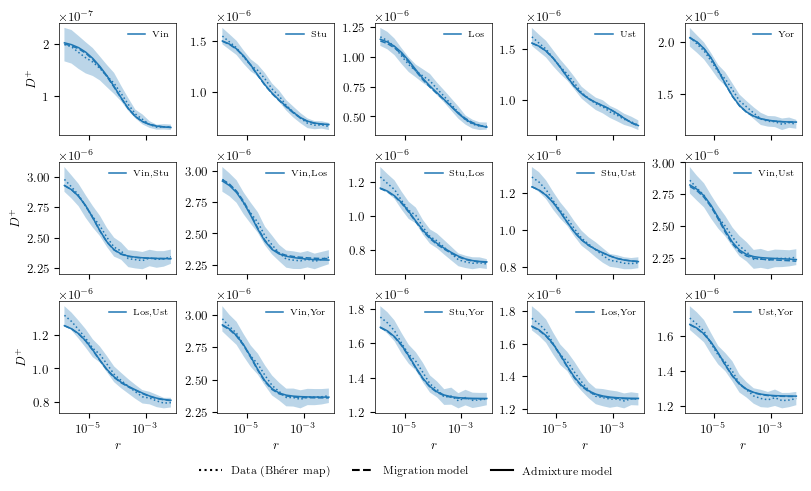

In [ ]:
def __plot_modern_human_model_residuals(axs):
    graph0 = "../models/modern_humans/main/best_fits/model_m_Bherer_fit_5.yaml"
    graph1 = "../models/modern_humans/main/best_fits/model_p_Bherer_fit_10.yaml"
    bherer = dpluspy.inference.load_stats(
        "../data/statistics/main/stats_Bherer_weighted.pkl", 
        graph=graph0, return_dict=True)
    model0 = dpluspy.inference.compute_bin_stats(
        graph0, sampled_demes=bherer["pop_ids"], bins=bherer["bins"], u=1.3e-8)
    residuals0 = compute_residuals(bherer, model0)
    plot_me0 = {
        "means": residuals0, "bins": bherer["bins"], "pop_ids": bherer["pop_ids"]}
    model1 = dpluspy.inference.compute_bin_stats(
        graph1, sampled_demes=bherer["pop_ids"], bins=bherer["bins"], u=1.3e-8)
    residuals1 = compute_residuals(bherer, model1)
    plot_me1 = {
        "means": residuals1, "bins": bherer["bins"], "pop_ids": bherer["pop_ids"]}
    
    labels = [x[:3] for x in bherer["pop_ids"]]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(plot_me0, axs, mapping_mh, colors, "--", labels=None, 
                      fill=False)
    plot_stats_on_axs(plot_me1, axs, mapping_mh, colors, "-", labels=labels, 
                      fill=False, ylabel="residual")
    return


def plot_modern_human_fits(axs):
    graph0 = "../models/modern_humans/main/best_fits/model_m_Bherer_fit_5.yaml"
    graph1 = "../models/modern_humans/main/best_fits/model_p_Bherer_fit_10.yaml"
    data = dpluspy.inference.load_stats(
        "../data/statistics/main/stats_Bherer_weighted.pkl", 
        graph=graph0, return_dict=True)
    if graph0 in _model_cache:
        _model0 = _model_cache[graph0]
    else:
        _model0 = dpluspy.inference.compute_bin_stats(graph0, 
            sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
        _model_cache[graph0] = _model0
    model0 = {
        "means": _model0, "bins": data["bins"], "pop_ids": data["pop_ids"]}    
    
    if graph1 in _model_cache:
        _model1 = _model_cache[graph1]
    else:
        _model1 = dpluspy.inference.compute_bin_stats(graph1, 
            sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
        _model_cache[graph1] = _model1
    model1 = {
        "means": _model1, "bins": data["bins"], "pop_ids": data["pop_ids"]}
    
    labels = [x[:3] for x in data["pop_ids"]]
    colors = ["tab:blue", "tab:orange"]
    plot_stats_on_axs(data, axs, mapping_sd, colors, ":", labels=None, 
                      fill=True)
    plot_stats_on_axs(model0, axs, mapping_sd, colors, "--", labels=None, 
                      fill=False)
    plot_stats_on_axs(model1, axs, mapping_sd, colors, "-", labels=labels, 
                      fill=False)
    return


fig, axs = plt.subplots(3, 5, figsize=(8, 4.5), layout="constrained", 
                        sharex=1)
plot_modern_human_fits(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Data (Bhérer map)",
                            linestyle=":"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Migration model",
                            linestyle="--"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Admixture model")
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.07))
plt.savefig("figures/figS7.pdf")

In [79]:
full_mle_bherer = "../models/full_model/round_6/fitted_models/full_model_round_6_Bherer_fit_13.yaml"
full_mle_zhoujhs = "../models/full_model/round_6/fitted_models/full_model_round_6_ZhouJHS_fit_47.yaml"

/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


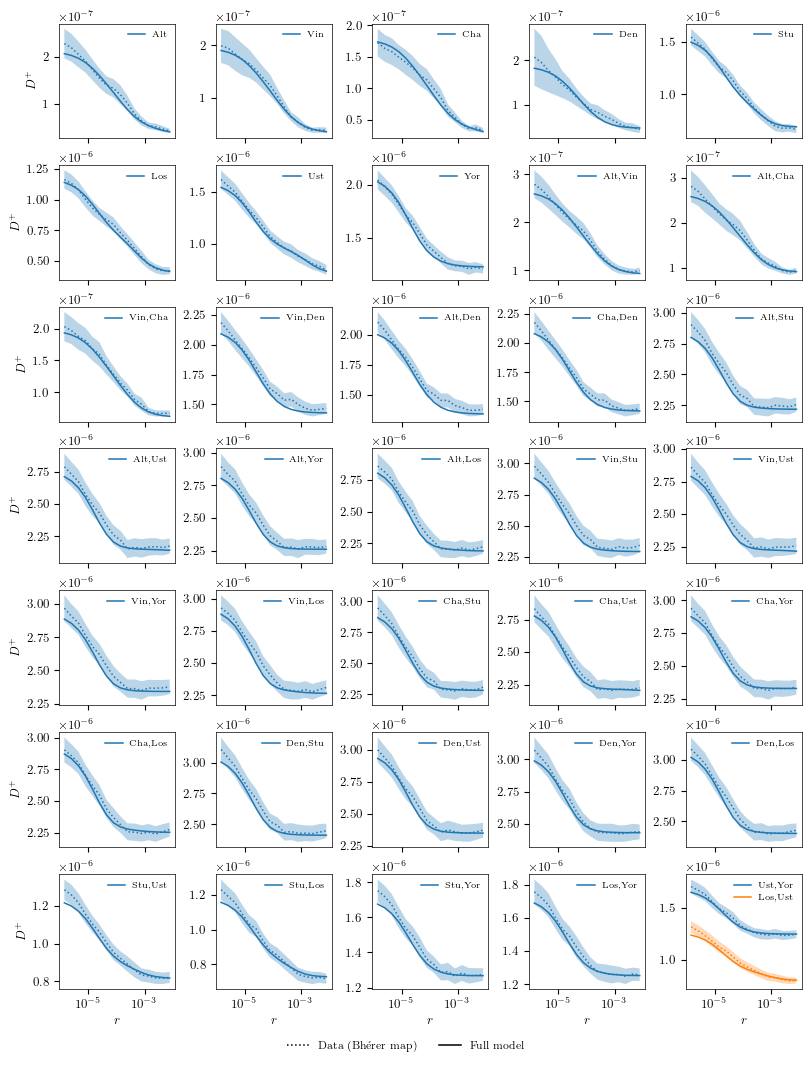

In [80]:
def plot_full_model_bherer(axs):
    data = load_pkl("../data/statistics/main/stats_Bherer_weighted.pkl")
    data = dpluspy.bootstrapping.subset_stats(
        data, to_pops=data["pop_ids"][:8], return_dict=True)
    graph = full_mle_bherer
    if graph in _model_cache:
        model = _model_cache[graph]
    else:
        model = dpluspy.inference.compute_bin_stats(graph, 
            sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
        _model_cache[graph] = model
    model = {"means": model, "bins": data["bins"], "pop_ids": data["pop_ids"][:8]}
    labels = [x[:3] for x in data["pop_ids"]]
    # labels = [str(x) for x in list(range(10))]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(data, axs, mapping, colors, ":", labels=None, fill=True)
    plot_stats_on_axs(model, axs, mapping, colors, "-", labels=labels, fill=False)
    return

fig, axs = plt.subplots(7, 5, figsize=(8, 10.25), layout="constrained", sharex=1)
plot_full_model_bherer(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Data (Bhérer map)",
                            linestyle=":"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Full model")
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.03))
plt.savefig("figures/figS8.pdf")

/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


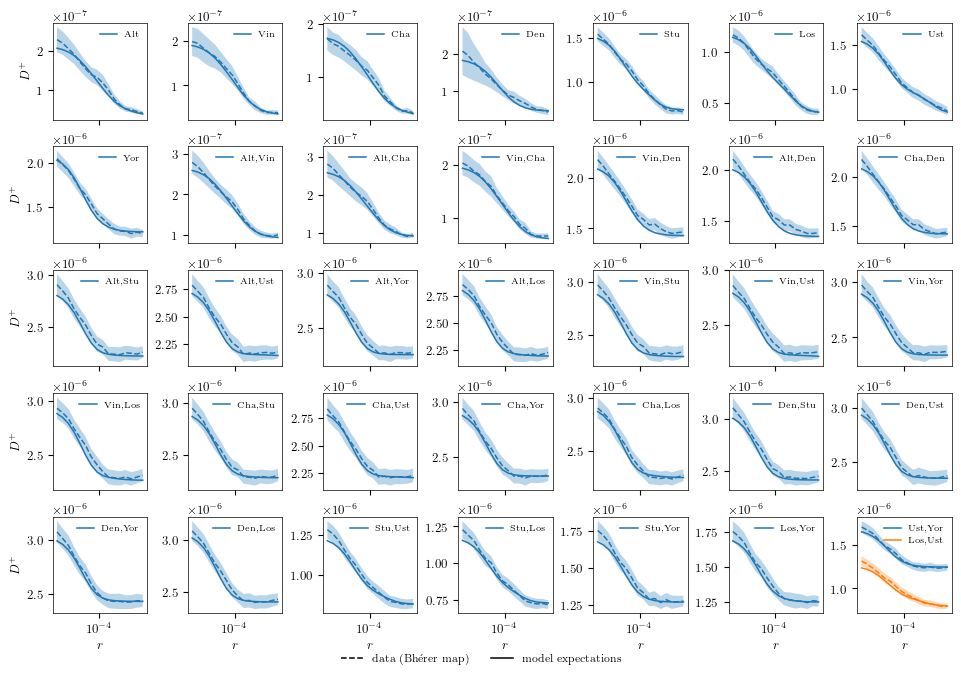

In [81]:
def plot_full_model_bherer(axs):
    bherer = load_pkl("../data/statistics/main/stats_Bherer_weighted.pkl")
    bherer = dpluspy.bootstrapping.subset_stats(
        bherer, to_pops=bherer["pop_ids"][:8], return_dict=True)
    graph = full_mle_bherer
    model = dpluspy.inference.compute_bin_stats(
        graph, sampled_demes=bherer["pop_ids"][:8], bins=bherer["bins"], u=1.3e-8)
    model = {"means": model, "bins": bherer["bins"], "pop_ids": bherer["pop_ids"][:8]}
    labels = [x[:3] for x in bherer["pop_ids"]]
    # labels = [str(x) for x in list(range(10))]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(bherer, axs, mapping, colors, "--", labels=None, fill=True)
    plot_stats_on_axs(model, axs, mapping, colors, "-", labels=labels, fill=False)
    return

fig, axs = plt.subplots(5, 7, figsize=(9.5, 6.5), layout="constrained", sharex=1)
plot_full_model_bherer(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="data (Bhérer map)",
                            linestyle="--"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="model expectations")
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.03))
plt.savefig("extra_figures/fullpanel.png", dpi=244)

/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


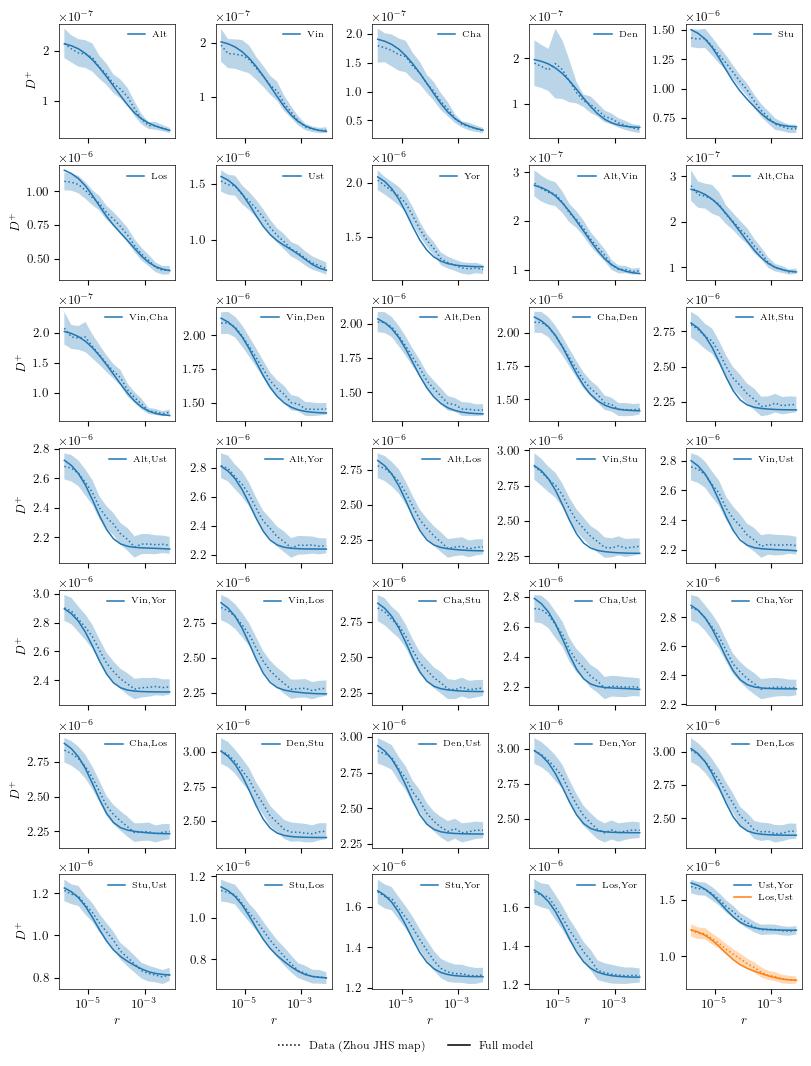

In [82]:
def plot_full_model_zhou_jhs(axs):
    data = load_pkl("../data/statistics/main/stats_ZhouJHS_weighted.pkl")
    data = dpluspy.bootstrapping.subset_stats(
        data, to_pops=data["pop_ids"][:8], return_dict=True)
    graph = full_mle_zhoujhs
    if graph in _model_cache:
        model = _model_cache[graph]
    else:
        model = dpluspy.inference.compute_bin_stats(graph, 
            sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
        _model_cache[graph] = model
    model = {"means": model, "bins": data["bins"], "pop_ids": data["pop_ids"][:8]}
    labels = [x[:3] for x in data["pop_ids"]]
    # labels = [str(x) for x in list(range(10))]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    plot_stats_on_axs(data, axs, mapping, colors, ":", labels=None, fill=True)
    plot_stats_on_axs(model, axs, mapping, colors, "-", labels=labels, fill=False)
    return

fig, axs = plt.subplots(7, 5, figsize=(8, 10.25), layout="constrained", sharex=1)
plot_full_model_zhou_jhs(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Data (Zhou JHS map)",
                            linestyle=":"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Full model")
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.03))
plt.savefig("figures/figS9.pdf")

/tmp/ipykernel_15027/1639287587.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(framealpha=0, fontsize="x-small")


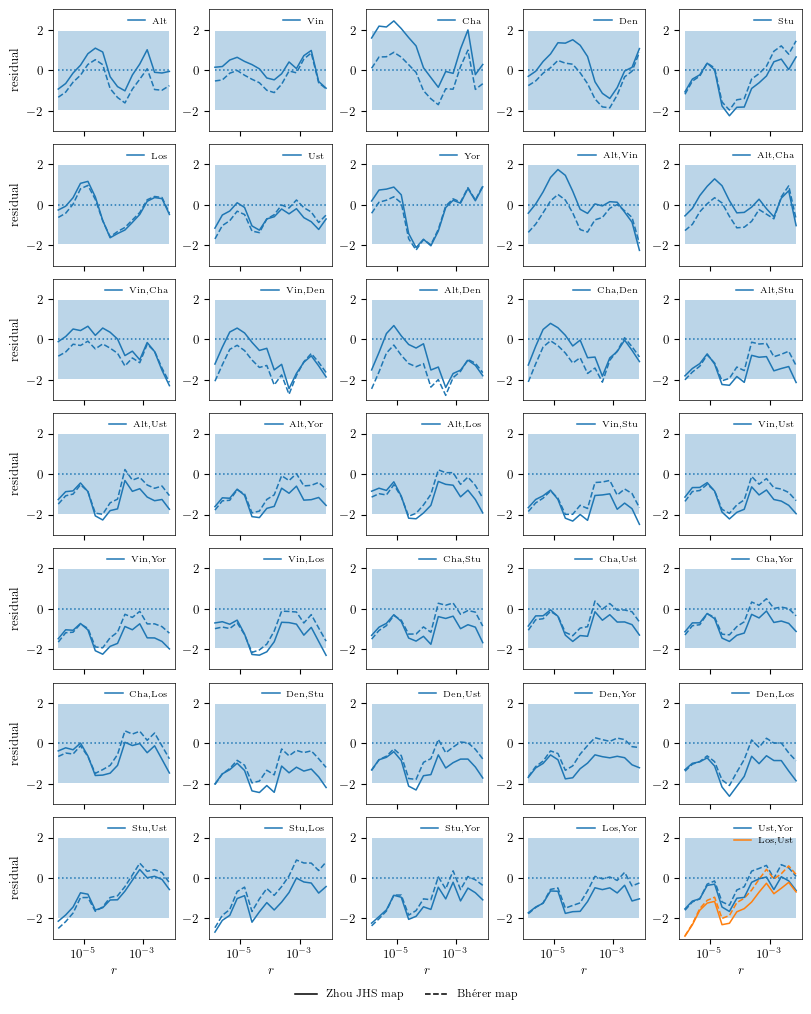

In [91]:
def plot_full_model_residuals(axs):
    data = load_pkl("../data/statistics/main/stats_Bherer_weighted.pkl")
    data = dpluspy.bootstrapping.subset_stats(
        data, to_pops=data["pop_ids"][:8], return_dict=True)
    graph = full_mle_bherer
    if graph in _model_cache:
        model = _model_cache[graph]
    else:
        model = dpluspy.inference.compute_bin_stats(graph, 
            sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
    residuals = compute_residuals(data, model)
    plot_me_bherer = {
        "means": residuals, "bins": data["bins"], "pop_ids": data["pop_ids"]}

    zhou = load_pkl("../data/statistics/main/stats_ZhouJHS_weighted.pkl")
    zhou = dpluspy.bootstrapping.subset_stats(
        data, to_pops=data["pop_ids"][:8], return_dict=True)
    graph = full_mle_zhoujhs
    if graph in _model_cache:
        model = _model_cache[graph]
    else:
        model = dpluspy.inference.compute_bin_stats(graph, 
            sampled_demes=data["pop_ids"], bins=data["bins"], u=1.3e-8)
        _model_cache[graph] = model
    residuals = compute_residuals(zhou, model)
    plot_me_zhou = {
        "means": residuals, "bins": data["bins"], "pop_ids": data["pop_ids"]}
    
    labels = [x[:3] for x in data["pop_ids"]]
    colors = ["tab:blue", "tab:orange"]
    fake_data = {"bins": data["bins"], "pop_ids": data["pop_ids"]}
    fake_data["means"] = [np.zeros(m.shape) for m in data["means"]]
    fake_data["varcovs"] = [np.ones(v.shape) for v in data["varcovs"]]
    _mapping = {x: mapping[x] for x in mapping if x != (5, 6)}
    plot_stats_on_axs(fake_data, axs, _mapping, colors, ":", labels=None, 
                      fill=True)
    plot_stats_on_axs(plot_me_bherer, axs, mapping, colors, "--", labels=None, 
                      fill=False)
    plot_stats_on_axs(plot_me_zhou, axs, mapping, colors, "-", labels=labels, 
                      fill=False, ylabel="residual")
    return


fig, axs = plt.subplots(7, 5, figsize=(8, 9.75), layout="constrained", 
                        sharex=1)
plot_full_model_residuals(axs)
labels = [
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Zhou JHS map"),
    matplotlib.lines.Line2D([], [], lw=lw, color="black", label="Bhérer map",
                            linestyle="--"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.03))
for ax in axs.flat:
    ax.set_ylim(-3, 3)
plt.savefig("figures/figS10.pdf")
